# 25CSAI01I – Introduction to Data Science
## COVID-19 Case Surveillance — Project 2

| Name | ID | Email |
|---|---|---|
| Mohamed Mahmoud | 249214 | mohamed249214@bue.edu.eg |
| Mohamed Yasser | 229267 | mohamed229267@bue.edu.eg |
| Mohamed Hesham | 247331 | mohamed247331@bue.edu.eg |
| Aly Mikaty | 245479 | aly245479@bue.edu.eg |

## Introduction

This notebook continues from Project 1, where we loaded, cleaned, and explored CDC individual-level COVID-19 case data (2,500 records).

In Phase 2 we:
1. Scrape weekly state-level COVID-19 case and death counts from **data.cdc.gov**.
2. Clean the scraped data.
3. Integrate it with the Phase 1 dataset.
4. Answer new questions on the integrated dataset.
5. Formulate and test a hypothesis.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


---
# Scrape Data from CDC

We scrape the *"Weekly United States COVID-19 Cases and Deaths by State"* dataset from `data.cdc.gov`, which gives us state-level weekly totals of cases and deaths.

In [2]:
HTML_URL = "https://data.cdc.gov/Case-Surveillance/Weekly-United-States-COVID-19-Cases-and-Deaths-by-/pwn4-m3yp/about_data"

headers = {
    "User-Agent": "Mozilla/5.0"
}

scraped_raw = None

try:
    response = requests.get(HTML_URL, headers=headers, timeout=20)
    print("HTTP Status:", response.status_code)

    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table')

    if table:
        headers_row = table.find('thead')
        col_names = [th.get_text(strip=True) for th in headers_row.find_all('th')]

        rows = []
        tbody = table.find('tbody')
        if tbody:
            for tr in tbody.find_all('tr'):
                cells = [td.get_text(strip=True) for td in tr.find_all(['td', 'th'])]
                if cells:
                    rows.append(cells)

        if col_names and rows:
            scraped_raw = pd.DataFrame(rows, columns=col_names)
            print("Records scraped:", len(scraped_raw))
        else:
            print("Table was empty, loading from CSV instead.")
    else:
        print("No table found, loading from CSV instead.")

except Exception as e:
    print("Could not scrape website:", e)

if scraped_raw is None or len(scraped_raw) == 0:
    print("Loading from local CSV file...")
    scraped_raw = pd.read_csv("pwn4-m3yp.csv")
    print("Records loaded:", len(scraped_raw))

scraped_raw.head()

HTTP Status: 200
No table found, loading from CSV instead.
Loading from local CSV file...
Records loaded: 1000


,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
0,2023-02-23T00:00:00.000,AZ,2023-02-16T00:00:00.000,2023-02-22T00:00:00.000,2434631.0,3716.0,33042.0,39.0,23150,0
1,2022-12-22T00:00:00.000,LA,2022-12-15T00:00:00.000,2022-12-21T00:00:00.000,1507707.0,4041.0,18345.0,21.0,21397,0
2,2023-02-23T00:00:00.000,GA,2023-02-16T00:00:00.000,2023-02-22T00:00:00.000,3061141.0,5298.0,42324.0,88.0,6800,0
3,2023-03-30T00:00:00.000,LA,2023-03-23T00:00:00.000,2023-03-29T00:00:00.000,1588259.0,2203.0,18858.0,23.0,5347,0
4,2023-02-02T00:00:00.000,LA,2023-01-26T00:00:00.000,2023-02-01T00:00:00.000,1548508.0,5725.0,18572.0,47.0,4507,0


---
# Clean the Scraped Data

First, let's take a look at what the raw data looks like before cleaning.

In [3]:
print("Shape:", scraped_raw.shape)

Shape: (1000, 10)


In [4]:
print(scraped_raw.dtypes)

date_updated            object
state                   object
start_date              object
end_date                object
tot_cases              float64
new_cases              float64
tot_deaths             float64
new_deaths             float64
new_historic_cases       int64
new_historic_deaths      int64
dtype: object


In [5]:
print(scraped_raw.isnull().sum())

date_updated           0
state                  0
start_date             0
end_date               0
tot_cases              0
new_cases              0
tot_deaths             0
new_deaths             0
new_historic_cases     0
new_historic_deaths    0
dtype: int64


In [6]:
scraped_raw.head(5)

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
0,2023-02-23T00:00:00.000,AZ,2023-02-16T00:00:00.000,2023-02-22T00:00:00.000,2434631.0,3716.0,33042.0,39.0,23150,0
1,2022-12-22T00:00:00.000,LA,2022-12-15T00:00:00.000,2022-12-21T00:00:00.000,1507707.0,4041.0,18345.0,21.0,21397,0
2,2023-02-23T00:00:00.000,GA,2023-02-16T00:00:00.000,2023-02-22T00:00:00.000,3061141.0,5298.0,42324.0,88.0,6800,0
3,2023-03-30T00:00:00.000,LA,2023-03-23T00:00:00.000,2023-03-29T00:00:00.000,1588259.0,2203.0,18858.0,23.0,5347,0
4,2023-02-02T00:00:00.000,LA,2023-01-26T00:00:00.000,2023-02-01T00:00:00.000,1548508.0,5725.0,18572.0,47.0,4507,0


In [7]:
scraped = scraped_raw.copy()

In [8]:
scraped['date_updated'] = pd.to_datetime(scraped['date_updated'], errors='coerce')
scraped['start_date'] = pd.to_datetime(scraped['start_date'], errors='coerce')
scraped['end_date'] = pd.to_datetime(scraped['end_date'], errors='coerce')

print("Date columns after fixing:")
print(scraped[['date_updated', 'start_date', 'end_date']].dtypes)

Date columns after fixing:
date_updated    datetime64[ns]
start_date      datetime64[ns]
end_date        datetime64[ns]
dtype: object


In [9]:
scraped['new_deaths'] = pd.to_numeric(scraped['new_deaths'], errors='coerce')

neg_count = (scraped['new_deaths'] < 0).sum()
print("Negative new_deaths values:", neg_count)

scraped.loc[scraped['new_deaths'] < 0, 'new_deaths'] = 0

print("Negative values after fix:", (scraped['new_deaths'] < 0).sum())

Negative new_deaths values: 1
Negative values after fix: 0


In [10]:
scraped['tot_cases'] = scraped['tot_cases'].astype(int)
scraped['new_cases'] = scraped['new_cases'].astype(int)
scraped['tot_deaths'] = scraped['tot_deaths'].astype(int)
scraped['new_deaths'] = scraped['new_deaths'].astype(int)

print("Numeric columns after converting:")
print(scraped[['tot_cases', 'new_cases', 'tot_deaths', 'new_deaths']].dtypes)

Numeric columns after converting:
tot_cases     int64
new_cases     int64
tot_deaths    int64
new_deaths    int64
dtype: object


In [11]:
state_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut',
    'DC': 'District of Columbia', 'DE': 'Delaware', 'FL': 'Florida',
    'GA': 'Georgia', 'GU': 'Guam', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana',
    'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire',
    'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NYC': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota',
    'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania',
    'PR': 'Puerto Rico', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'AS': 'American Samoa', 'VI': 'U.S. Virgin Islands'
}

scraped['state_full'] = scraped['state'].map(state_map)

print("States that could not be mapped:", scraped['state_full'].isnull().sum())
scraped[['state', 'state_full']].drop_duplicates().head(10)

States that could not be mapped: 0


,state,state_full
0,AZ,Arizona
1,LA,Louisiana
2,GA,Georgia
7,NV,Nevada
8,FL,Florida
9,NYC,New York
10,KS,Kansas
11,VA,Virginia
12,OK,Oklahoma
14,IL,Illinois


In [12]:
scraped.rename(columns={'state': 'state_abbr', 'state_full': 'state'}, inplace=True)

scraped.drop(columns=['new_historic_cases', 'new_historic_deaths'], inplace=True)

scraped.dropna(subset=['state'], inplace=True)
scraped.reset_index(drop=True, inplace=True)

print("Final dataset shape:", scraped.shape)

Final dataset shape: (1000, 9)


In [13]:
print("Missing values after cleaning:")
print(scraped.isnull().sum())

Missing values after cleaning:
date_updated    0
state_abbr      0
start_date      0
end_date        0
tot_cases       0
new_cases       0
tot_deaths      0
new_deaths      0
state           0
dtype: int64


In [14]:
scraped.describe()

,date_updated,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths
count,1000,1000,1000,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,2021-09-06 12:01:26.400000,2021-08-30 12:01:26.400000,2021-09-05 12:01:26.400000,1.036858e+06,16321.209000,13579.647000,162.483000
min,2020-01-23 00:00:00,2020-01-16 00:00:00,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000,0.000000
25%,2020-11-12 00:00:00,2020-11-05 00:00:00,2020-11-11 00:00:00,8.320000e+03,425.500000,64.750000,0.000000
50%,2021-09-05 12:00:00,2021-08-29 12:00:00,2021-09-04 12:00:00,2.945670e+05,3220.000000,5434.500000,35.000000
75%,2022-06-23 00:00:00,2022-06-16 00:00:00,2022-06-22 00:00:00,1.163466e+06,11554.000000,18729.250000,160.250000
max,2023-05-11 00:00:00,2023-05-04 00:00:00,2023-05-10 00:00:00,1.093023e+07,790954.000000,93490.000000,3665.000000
std,NaN,NaN,NaN,1.868304e+06,54866.853347,20664.067002,368.847682


---
# Integrate Datasets

We combine the cleaned scraped dataset with the Phase 1 dataset.

In [15]:
df = pd.read_excel("DataSet_COVID19.xlsx")

df.head()

,cdc_case_earliest_dt,cdc_report_dt,pos_spec_dt,onset_dt,current_status,sex,age_group,race_ethnicity_combined,hosp_yn,icu_yn,death_yn,medcond_yn,state,symptom_severity,vaccination_status,variant
0,2020-03-22,2021-01-16,2020-03-24,2020-03-22,Laboratory-confirmed case,Male,40 - 49 Years,Unknown,Yes,No,No,Yes,Florida,Moderate,Unvaccinated,Original
1,2020-12-29,2021-12-06,2021-01-07,2020-12-29,Laboratory-confirmed case,Female,60 - 69 Years,Unknown,No,No,No,No,North Carolina,Moderate,Unvaccinated,Beta
2,2020-05-04,2021-12-06,2020-05-07,2020-05-04,Laboratory-confirmed case,Male,40 - 49 Years,Unknown,No,No,No,No,Pennsylvania,Mild,Unvaccinated,Original
3,2020-04-07,2021-01-20,2020-04-10,2020-04-07,Laboratory-confirmed case,Male,50 - 59 Years,Unknown,No,No,No,Yes,Illinois,Mild,Unvaccinated,Original
4,2020-12-02,2021-12-06,2020-12-07,2020-12-02,Laboratory-confirmed case,Female,60 - 69 Years,Unknown,No,No,No,Yes,California,Moderate,Partially Vaccinated,Beta


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   cdc_case_earliest_dt     2500 non-null   datetime64[ns]
 1   cdc_report_dt            2500 non-null   datetime64[ns]
 2   pos_spec_dt              1973 non-null   datetime64[ns]
 3   onset_dt                 2300 non-null   datetime64[ns]
 4   current_status           2500 non-null   object        
 5   sex                      2500 non-null   object        
 6   age_group                2500 non-null   object        
 7   race_ethnicity_combined  2500 non-null   object        
 8   hosp_yn                  2500 non-null   object        
 9   icu_yn                   2500 non-null   object        
 10  death_yn                 2500 non-null   object        
 11  medcond_yn               2500 non-null   object        
 12  state                    2500 non-

In [17]:
df.rename(columns={'cdc_case_earliest_dt ': 'cdc_case_earliest_dt'}, inplace=True)

print("Column names fixed.")

Column names fixed.


In [18]:
df.drop(columns=['race_ethnicity_combined', 'cdc_report_dt'], inplace=True)

print("Columns dropped.")

Columns dropped.


In [19]:
df.dropna(subset=['pos_spec_dt'], inplace=True)

print("Rows after removing missing dates:", len(df))

Rows after removing missing dates: 1973


In [20]:
print("Duplicates before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 3
Duplicates after: 0


In [21]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

print("Whitespace removed from text columns.")

Whitespace removed from text columns.


In [22]:
df['hosp_yn_enc'] = df['hosp_yn'].map({'Yes': 1, 'No': 0})
df['icu_yn_enc'] = df['icu_yn'].map({'Yes': 1, 'No': 0})
df['death_yn_enc'] = df['death_yn'].map({'Yes': 1, 'No': 0})
df['medcond_yn_enc'] = df['medcond_yn'].map({'Yes': 1, 'No': 0})

df['sex_enc'] = df['sex'].map({'Female': 0, 'Male': 1})

print("Encoding done.")

Encoding done.


In [23]:
age_order = {
    '40 - 49 Years': 0,
    '50 - 59 Years': 1,
    '60 - 69 Years': 2,
    '70 - 79 Years': 3,
    '80+ Years': 4
}

df['age_group_enc'] = df['age_group'].map(age_order)

print("Age group encoding done.")

Age group encoding done.


In [24]:
df['year_month'] = df['cdc_case_earliest_dt'].dt.strftime('%Y-%m')

print("Phase 1 dataset shape:", df.shape)
df.head()

Phase 1 dataset shape: (1970, 21)


,cdc_case_earliest_dt,pos_spec_dt,onset_dt,current_status,sex,age_group,hosp_yn,icu_yn,death_yn,medcond_yn,...,symptom_severity,vaccination_status,variant,hosp_yn_enc,icu_yn_enc,death_yn_enc,medcond_yn_enc,sex_enc,age_group_enc,year_month
0,2020-03-22,2020-03-24,2020-03-22,Laboratory-confirmed case,Male,40 - 49 Years,Yes,No,No,Yes,...,Moderate,Unvaccinated,Original,1,0,0,1,1,0,2020-03
1,2020-12-29,2021-01-07,2020-12-29,Laboratory-confirmed case,Female,60 - 69 Years,No,No,No,No,...,Moderate,Unvaccinated,Beta,0,0,0,0,0,2,2020-12
2,2020-05-04,2020-05-07,2020-05-04,Laboratory-confirmed case,Male,40 - 49 Years,No,No,No,No,...,Mild,Unvaccinated,Original,0,0,0,0,1,0,2020-05
3,2020-04-07,2020-04-10,2020-04-07,Laboratory-confirmed case,Male,50 - 59 Years,No,No,No,Yes,...,Mild,Unvaccinated,Original,0,0,0,1,1,1,2020-04
4,2020-12-02,2020-12-07,2020-12-02,Laboratory-confirmed case,Female,60 - 69 Years,No,No,No,Yes,...,Moderate,Partially Vaccinated,Beta,0,0,0,1,0,2,2020-12


In [25]:
p1_state = df.groupby('state').agg(
    total_cases_p1=('death_yn_enc', 'count'),
    total_deaths_p1=('death_yn_enc', 'sum'),
    total_hosp_p1=('hosp_yn_enc', 'sum'),
    total_icu_p1=('icu_yn_enc', 'sum'),
    total_medcond_p1=('medcond_yn_enc', 'sum')
).reset_index()

print("Phase 1 state summary shape:", p1_state.shape)
p1_state.head()

Phase 1 state summary shape: (10, 6)


,state,total_cases_p1,total_deaths_p1,total_hosp_p1,total_icu_p1,total_medcond_p1
0,California,372,43,87,39,212
1,Florida,244,31,68,27,143
2,Georgia,151,20,39,17,78
3,Illinois,189,30,54,18,108
4,Michigan,113,11,27,9,57


In [26]:
p1_state['death_rate_p1'] = (p1_state['total_deaths_p1'] / p1_state['total_cases_p1'] * 100).round(2)
p1_state['hosp_rate_p1'] = (p1_state['total_hosp_p1'] / p1_state['total_cases_p1'] * 100).round(2)

p1_state.head()

,state,total_cases_p1,total_deaths_p1,total_hosp_p1,total_icu_p1,total_medcond_p1,death_rate_p1,hosp_rate_p1
0,California,372,43,87,39,212,11.56,23.39
1,Florida,244,31,68,27,143,12.70,27.87
2,Georgia,151,20,39,17,78,13.25,25.83
3,Illinois,189,30,54,18,108,15.87,28.57
4,Michigan,113,11,27,9,57,9.73,23.89


In [27]:
p2_state = scraped.groupby('state').agg(
    total_cases_p2=('new_cases', 'sum'),
    total_deaths_p2=('new_deaths', 'sum'),
    weeks_reported=('start_date', 'count'),
    earliest_week=('start_date', 'min'),
    latest_week=('end_date', 'max')
).reset_index()

print("Phase 2 state summary shape:", p2_state.shape)
p2_state.head()

Phase 2 state summary shape: (16, 6)


,state,total_cases_p2,total_deaths_p2,weeks_reported,earliest_week,latest_week
0,Alabama,1575268,20535,170,2020-01-16,2023-05-10
1,Alaska,291142,1460,164,2020-01-30,2023-05-10
2,American Samoa,8331,34,173,2020-01-16,2023-05-10
3,Arizona,2451004,33451,173,2020-01-16,2023-05-10
4,Arkansas,990589,12997,168,2020-01-16,2023-05-10


In [28]:
integrated = pd.merge(p1_state, p2_state, on='state', how='inner')

print("States in Phase 1:", len(p1_state))
print("States in Phase 2:", len(p2_state))
print("States after merge:", len(integrated))

integrated.head()

States in Phase 1: 10
States in Phase 2: 16
States after merge: 5


,state,total_cases_p1,total_deaths_p1,total_hosp_p1,total_icu_p1,total_medcond_p1,death_rate_p1,hosp_rate_p1,total_cases_p2,total_deaths_p2,weeks_reported,earliest_week,latest_week
0,California,372,43,87,39,212,11.56,23.39,10930234,93490,135,2020-01-16,2022-08-17
1,Florida,244,31,68,27,143,12.70,27.87,6937,0,1,2023-05-04,2023-05-10
2,Georgia,151,20,39,17,78,13.25,25.83,5298,88,1,2023-02-16,2023-02-22
3,Illinois,189,30,54,18,108,15.87,28.57,4192,60,1,2023-04-20,2023-04-26
4,New York,225,24,53,19,122,10.67,23.56,14590,91,1,2022-10-20,2022-10-26


In [29]:
p1_only = set(p1_state['state']) - set(p2_state['state'])
p2_only = set(p2_state['state']) - set(p1_state['state'])

print("States in Phase 1 only:", sorted(p1_only))
print()
print("States in Phase 2 only:", sorted(p2_only))

States in Phase 1 only: ['Michigan', 'North Carolina', 'Ohio', 'Pennsylvania', 'Texas']

States in Phase 2 only: ['Alabama', 'Alaska', 'American Samoa', 'Arizona', 'Arkansas', 'District of Columbia', 'Kansas', 'Louisiana', 'Nevada', 'Oklahoma', 'Virginia']


In [30]:
print("Integrated dataset shape:", integrated.shape)

print()
print("Missing values:")
print(integrated.isnull().sum())

Integrated dataset shape: (5, 13)

Missing values:
state               0
total_cases_p1      0
total_deaths_p1     0
total_hosp_p1       0
total_icu_p1        0
total_medcond_p1    0
death_rate_p1       0
hosp_rate_p1        0
total_cases_p2      0
total_deaths_p2     0
weeks_reported      0
earliest_week       0
latest_week         0
dtype: int64


In [31]:
integrated.describe()

,total_cases_p1,total_deaths_p1,total_hosp_p1,total_icu_p1,total_medcond_p1,death_rate_p1,hosp_rate_p1,total_cases_p2,total_deaths_p2,weeks_reported,earliest_week,latest_week
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000e+00,5.00000,5.000000,5,5
mean,236.200000,29.600000,60.200000,24.000000,132.600000,12.81000,25.844000,2.192250e+06,18745.80000,27.800000,2022-07-09 19:12:00,2023-01-19 09:36:00
min,151.000000,20.000000,39.000000,17.000000,78.000000,10.67000,23.390000,4.192000e+03,0.00000,1.000000,2020-01-16 00:00:00,2022-08-17 00:00:00
25%,189.000000,24.000000,53.000000,18.000000,108.000000,11.56000,23.560000,5.298000e+03,60.00000,1.000000,2022-10-20 00:00:00,2022-10-26 00:00:00
50%,225.000000,30.000000,54.000000,19.000000,122.000000,12.70000,25.830000,6.937000e+03,88.00000,1.000000,2023-02-16 00:00:00,2023-02-22 00:00:00
75%,244.000000,31.000000,68.000000,27.000000,143.000000,13.25000,27.870000,1.459000e+04,91.00000,1.000000,2023-04-20 00:00:00,2023-04-26 00:00:00
max,372.000000,43.000000,87.000000,39.000000,212.000000,15.87000,28.570000,1.093023e+07,93490.00000,135.000000,2023-05-04 00:00:00,2023-05-10 00:00:00
std,83.837343,8.734987,18.157643,9.273618,50.277231,1.98188,2.386143,4.884683e+06,41783.29402,59.926622,NaN,NaN


---
# Analysis Questions

---
## Mohamed Mahmoud Rezk

**Assigned Questions:** Q1, Q2, Q3

### Q1: Which states had the highest death rate in Phase 1, and how does that compare to Phase 2 total deaths?

States are sorted by Phase 1 death rate and plotted against Phase 2 total deaths.

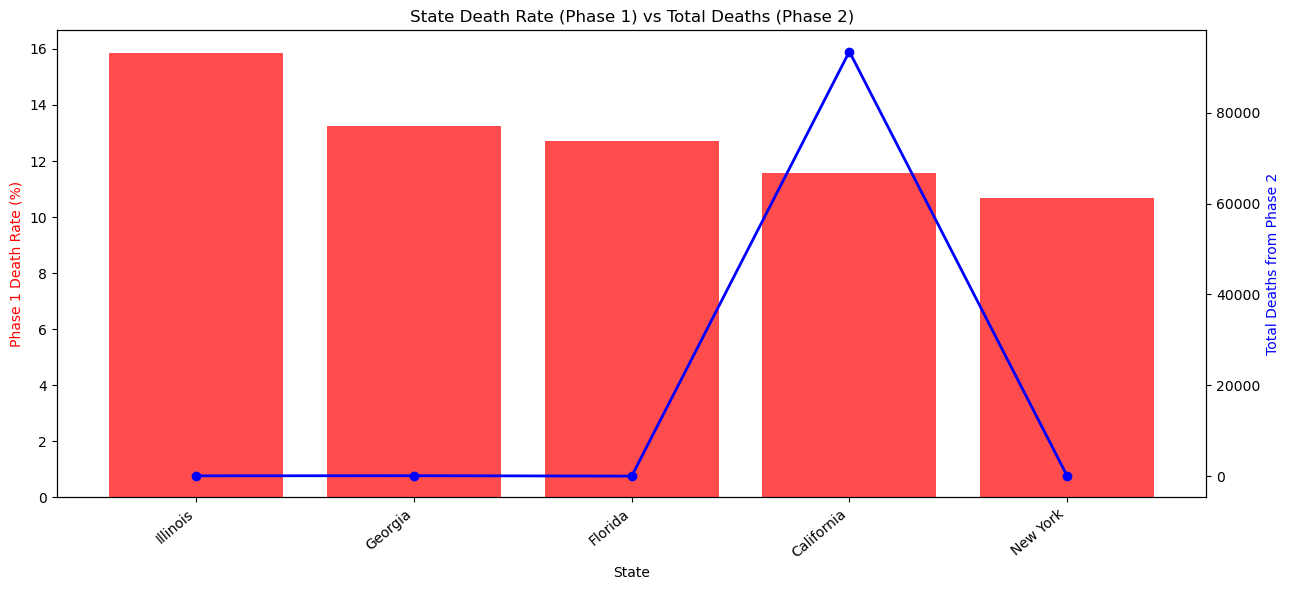

In [32]:
sorted_int = integrated.sort_values('death_rate_p1', ascending=False)

fig, ax1 = plt.subplots(figsize=(13, 6))

x = np.arange(len(sorted_int))

ax1.bar(x, sorted_int['death_rate_p1'], color='red', alpha=0.7, label='P1 Death Rate (%)')
ax1.set_xlabel('State')
ax1.set_ylabel('Phase 1 Death Rate (%)', color='red')
ax1.set_xticks(x)
ax1.set_xticklabels(sorted_int['state'], rotation=40, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, sorted_int['total_deaths_p2'], color='blue', linewidth=2,
         marker='o', label='Scraped Total Deaths')
ax2.set_ylabel('Total Deaths from Phase 2', color='blue')

plt.title('State Death Rate (Phase 1) vs Total Deaths (Phase 2)')
plt.tight_layout()
plt.savefig('Q1_state_deathrate_vs_scraped_deaths.png', dpi=150, bbox_inches='tight')
plt.show()

### Q2: How do weekly new cases trend over time for the top 5 states by total scraped cases?

In [33]:
top5_states = integrated.nlargest(5, 'total_cases_p2')['state'].tolist()
print("Top 5 states:", top5_states)

Top 5 states: ['California', 'New York', 'Florida', 'Georgia', 'Illinois']


In [34]:
top5_weekly = scraped[scraped['state'].isin(top5_states)].copy()
top5_weekly = top5_weekly.sort_values('start_date')

top5_weekly.head()

,date_updated,state_abbr,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,state
864,2020-01-23,CA,2020-01-16,2020-01-22,0,0,0,0,California
865,2020-01-30,CA,2020-01-23,2020-01-29,2,2,0,0,California
866,2020-02-06,CA,2020-01-30,2020-02-05,8,6,0,0,California
867,2020-02-13,CA,2020-02-06,2020-02-12,16,8,0,0,California
868,2020-02-20,CA,2020-02-13,2020-02-19,30,14,0,0,California


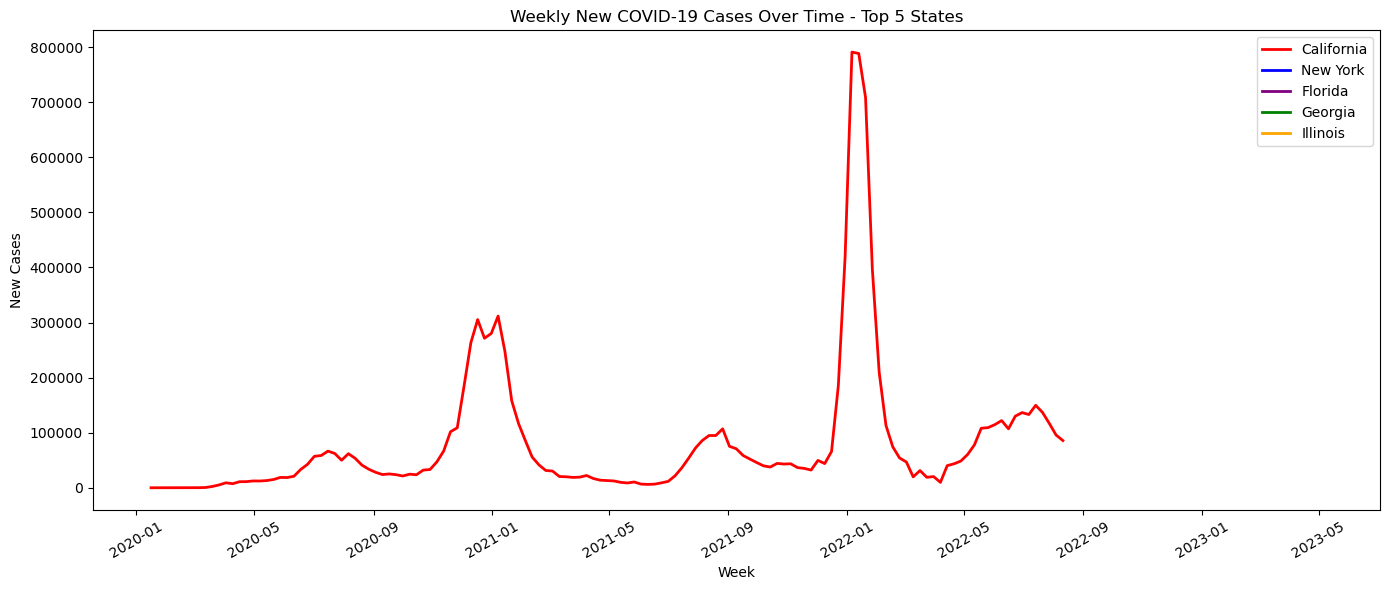

In [35]:
plt.figure(figsize=(14, 6))

colors = ['red', 'blue', 'purple', 'green', 'orange']

for i, state in enumerate(top5_states):
    state_data = top5_weekly[top5_weekly['state'] == state]
    plt.plot(state_data['start_date'], state_data['new_cases'],
             label=state, color=colors[i], linewidth=2)

plt.title('Weekly New COVID-19 Cases Over Time - Top 5 States')
plt.xlabel('Week')
plt.ylabel('New Cases')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('Q2_weekly_cases_top5_states.png', dpi=150, bbox_inches='tight')
plt.show()

### Q3: What is the correlation matrix across all key numeric metrics in the integrated dataset?

In [36]:
cols_to_use = [
    'total_cases_p1', 'total_deaths_p1', 'total_hosp_p1', 'total_icu_p1',
    'death_rate_p1', 'hosp_rate_p1', 'icu_rate_p1',
    'total_cases_p2', 'total_deaths_p2', 'death_rate_p2'
]

cols_present = [c for c in cols_to_use if c in integrated.columns]

corr_matrix = integrated[cols_present].corr()

corr_matrix

,total_cases_p1,total_deaths_p1,total_hosp_p1,total_icu_p1,death_rate_p1,hosp_rate_p1,total_cases_p2,total_deaths_p2
total_cases_p1,1.000000,0.919136,0.965619,0.963374,-0.494356,-0.524054,0.905677,0.905266
total_deaths_p1,0.919136,1.000000,0.963704,0.919697,-0.114374,-0.192295,0.857464,0.857203
total_hosp_p1,0.965619,0.963704,1.000000,0.960585,-0.328250,-0.289221,0.825140,0.824662
total_icu_p1,0.963374,0.919697,0.960585,1.000000,-0.405622,-0.401863,0.904216,0.903860
death_rate_p1,-0.494356,-0.114374,-0.328250,-0.405622,1.000000,0.849420,-0.353265,-0.352722
hosp_rate_p1,-0.524054,-0.192295,-0.289221,-0.401863,0.849420,1.000000,-0.575492,-0.575396
total_cases_p2,0.905677,0.857464,0.825140,0.904216,-0.353265,-0.575492,1.000000,1.000000
total_deaths_p2,0.905266,0.857203,0.824662,0.903860,-0.352722,-0.575396,1.000000,1.000000


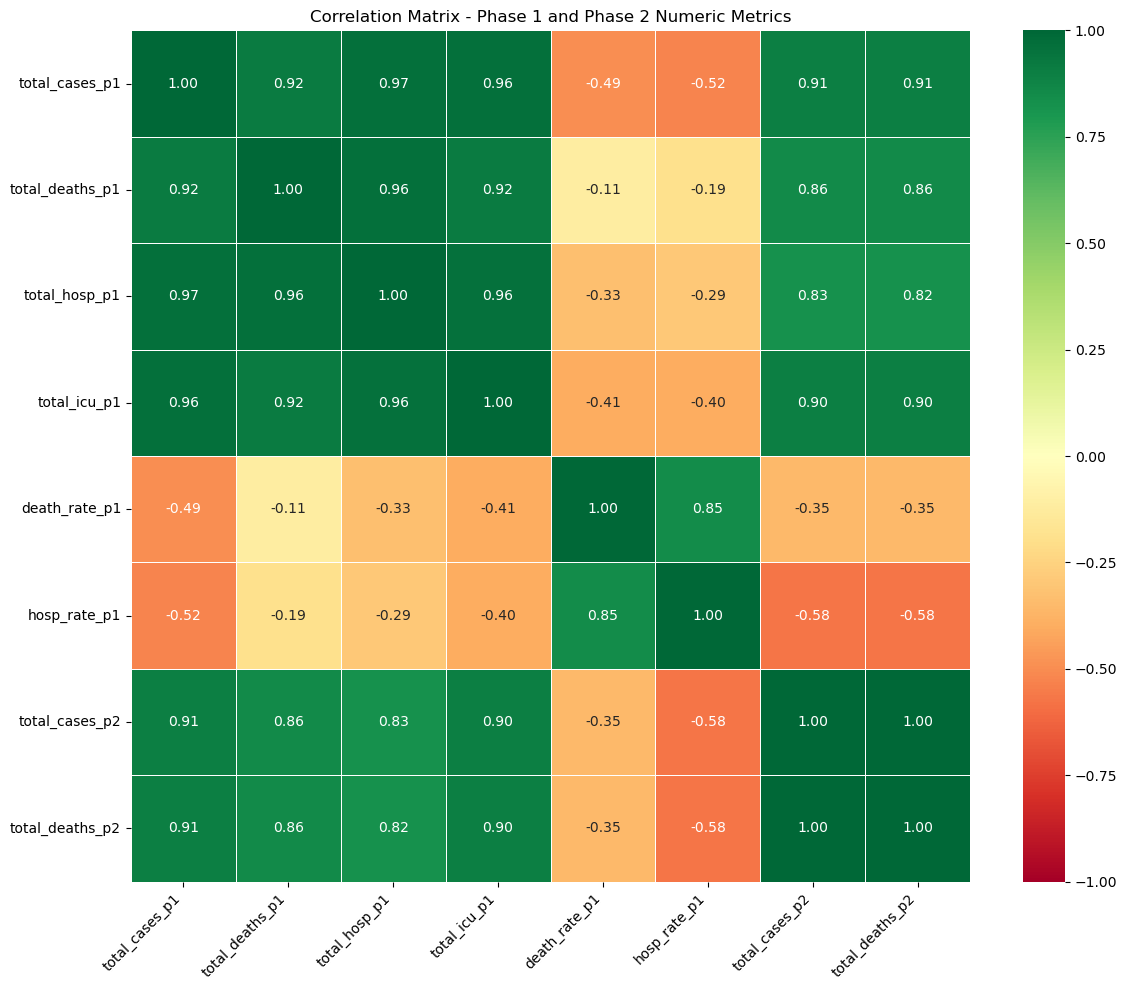

In [37]:
plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5)

plt.title('Correlation Matrix - Phase 1 and Phase 2 Numeric Metrics')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Q3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Aly Mikaty

**Assigned Questions:** Q4, Q5, Q6

### Q4: What is the relationship between Phase 1 hospitalization rate and Phase 2 death rate by state?

In [38]:
if 'death_rate_p2' not in integrated.columns:
    integrated['death_rate_p2'] = (integrated['total_deaths_p2'] / integrated['total_cases_p2'] * 100).round(2)

integrated[['state', 'hosp_rate_p1', 'death_rate_p2']].head()

,state,hosp_rate_p1,death_rate_p2
0,California,23.39,0.86
1,Florida,27.87,0.00
2,Georgia,25.83,1.66
3,Illinois,28.57,1.43
4,New York,23.56,0.62


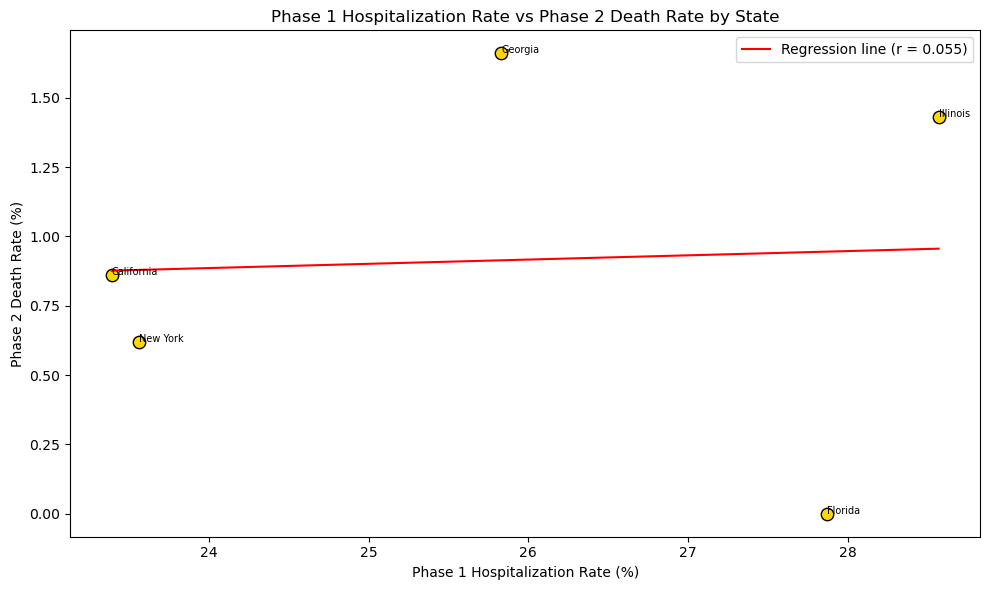

Pearson r = 0.0552
p-value = 0.9297


In [39]:
plt.figure(figsize=(10, 6))

plt.scatter(integrated['hosp_rate_p1'], integrated['death_rate_p2'], color='gold', edgecolors='black', s=80)

for i, row in integrated.iterrows():
    plt.annotate(row['state'], (row['hosp_rate_p1'], row['death_rate_p2']), fontsize=7)

m, b, r, p_val, se = stats.linregress(integrated['hosp_rate_p1'], integrated['death_rate_p2'])
x_line = np.linspace(integrated['hosp_rate_p1'].min(), integrated['hosp_rate_p1'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', label='Regression line (r = ' + str(round(r, 3)) + ')')

plt.title('Phase 1 Hospitalization Rate vs Phase 2 Death Rate by State')
plt.xlabel('Phase 1 Hospitalization Rate (%)')
plt.ylabel('Phase 2 Death Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('Q4_hosp_rate_vs_p2_death_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pearson r =", round(r, 4))
print("p-value =", round(p_val, 4))

### Q5: How does the death rate vary across COVID-19 variants, and does it differ by sex?

In [40]:
variant_sex = df.groupby(['variant', 'sex']).agg(
    total=('death_yn_enc', 'count'),
    deaths=('death_yn_enc', 'sum')
).reset_index()

variant_sex['death_rate'] = (variant_sex['deaths'] / variant_sex['total'] * 100).round(2)

variant_sex = variant_sex[variant_sex['sex'].isin(['Male', 'Female'])]

variant_sex.head()

,variant,sex,total,deaths,death_rate
0,Alpha,Female,385,64,16.62
1,Alpha,Male,342,13,3.80
2,Beta,Female,121,19,15.70
3,Beta,Male,83,5,6.02
4,Original,Female,480,118,24.58


In [41]:
pivot = variant_sex.pivot(index='variant', columns='sex', values='death_rate').fillna(0)
pivot = pivot.sort_values('Male', ascending=False)

pivot

sex,Female,Male
variant,,
Original,24.58,6.62
Beta,15.70,6.02
Alpha,16.62,3.80


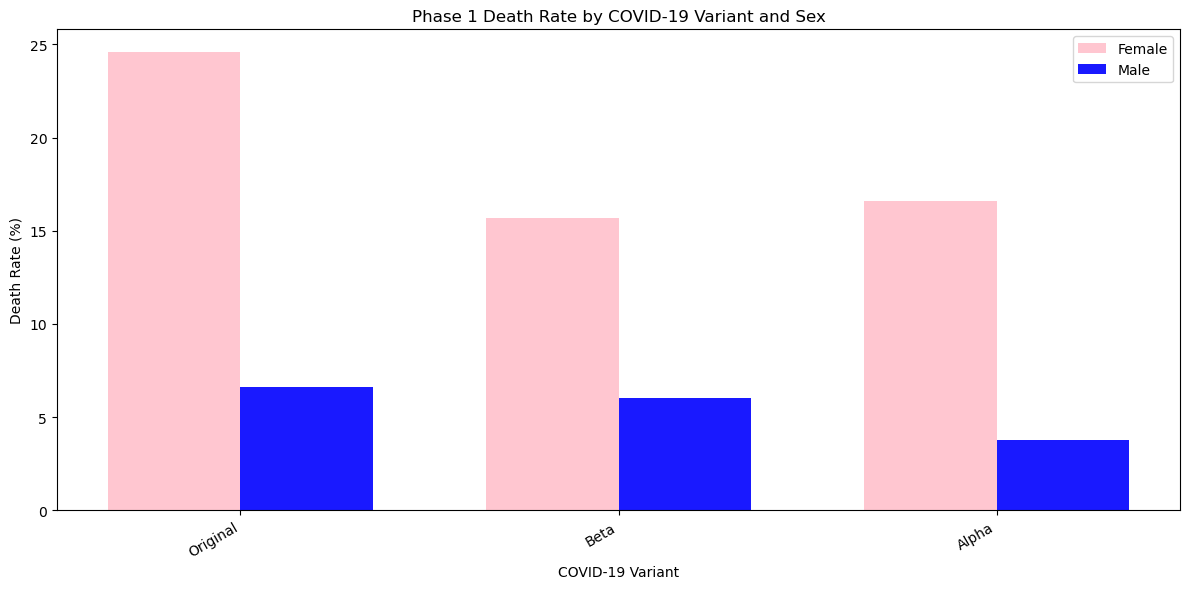

In [42]:
x = np.arange(len(pivot))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, pivot['Female'], width, label='Female', color='pink', alpha=0.9)
plt.bar(x + width/2, pivot['Male'], width, label='Male', color='blue', alpha=0.9)

plt.xticks(x, pivot.index, rotation=30, ha='right')
plt.xlabel('COVID-19 Variant')
plt.ylabel('Death Rate (%)')
plt.title('Phase 1 Death Rate by COVID-19 Variant and Sex')
plt.legend()
plt.tight_layout()
plt.savefig('Q5_death_rate_variant_sex.png', dpi=150, bbox_inches='tight')
plt.show()

### Q6: How do Phase 2 total cases compare to Phase 1 sampled case counts across matched states?

In [43]:
sorted_comp = integrated.sort_values('total_cases_p2', ascending=True)

sorted_comp[['state', 'total_cases_p1', 'total_cases_p2']].head()

,state,total_cases_p1,total_cases_p2
3,Illinois,189,4192
2,Georgia,151,5298
1,Florida,244,6937
4,New York,225,14590
0,California,372,10930234


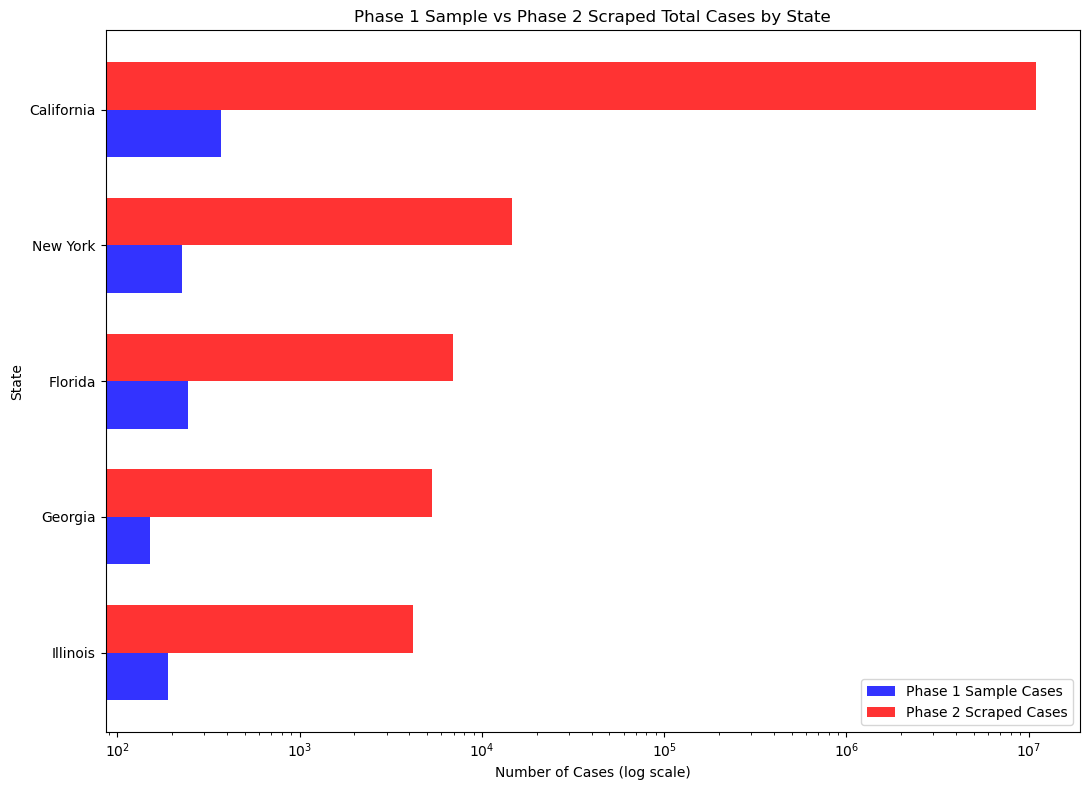

In [44]:
y = np.arange(len(sorted_comp))
height = 0.35

plt.figure(figsize=(11, 8))

plt.barh(y - height/2, sorted_comp['total_cases_p1'], height, label='Phase 1 Sample Cases', color='blue', alpha=0.8)
plt.barh(y + height/2, sorted_comp['total_cases_p2'], height, label='Phase 2 Scraped Cases', color='red', alpha=0.8)

plt.yticks(y, sorted_comp['state'])
plt.xlabel('Number of Cases (log scale)')
plt.ylabel('State')
plt.xscale('log')
plt.title('Phase 1 Sample vs Phase 2 Scraped Total Cases by State')
plt.legend()
plt.tight_layout()
plt.savefig('Q6_p1_vs_p2_cases_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Mohamed Yasser

**Assigned Questions:** Q7, Q8, Q9

### Q7: Which states had the highest ICU admission rate in Phase 1, and how does that relate to Phase 2 total deaths?

In [45]:
integrated['icu_rate_p1'] = (integrated['total_icu_p1'] / integrated['total_cases_p1'] * 100).round(2)

integrated[['state', 'icu_rate_p1']].sort_values('icu_rate_p1', ascending=False).head()

,state,icu_rate_p1
2,Georgia,11.26
1,Florida,11.07
0,California,10.48
3,Illinois,9.52
4,New York,8.44


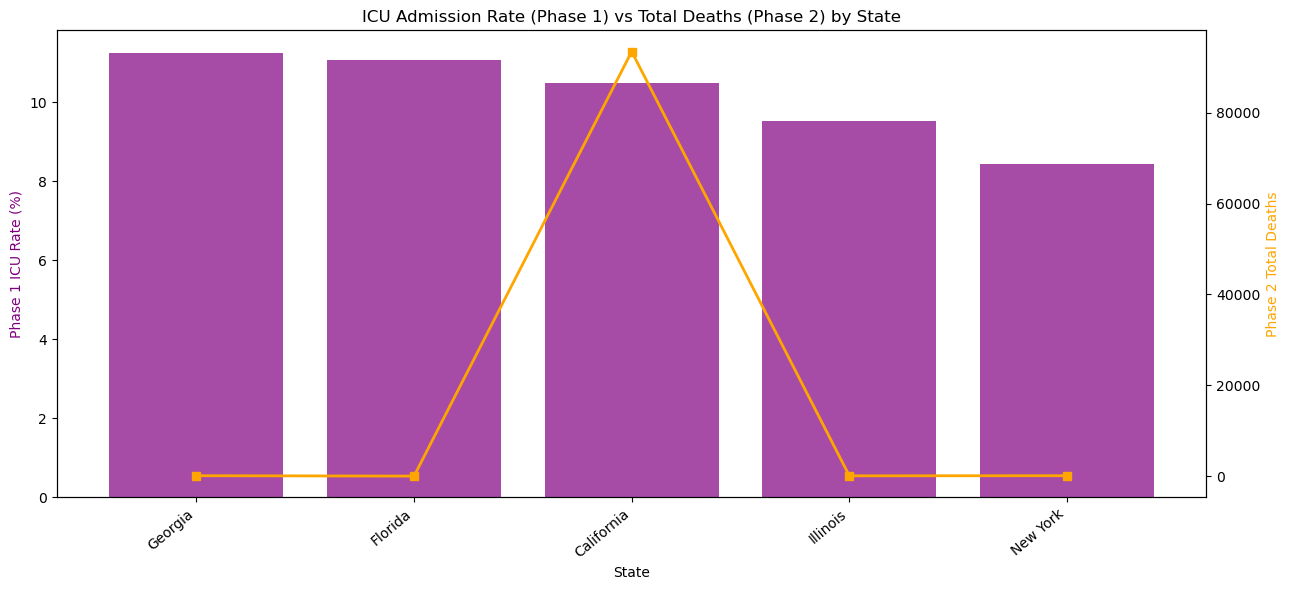

In [46]:
sorted_icu = integrated.sort_values('icu_rate_p1', ascending=False)

x = np.arange(len(sorted_icu))

fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.bar(x, sorted_icu['icu_rate_p1'], color='purple', alpha=0.7, label='P1 ICU Rate (%)')
ax1.set_xlabel('State')
ax1.set_ylabel('Phase 1 ICU Rate (%)', color='purple')
ax1.set_xticks(x)
ax1.set_xticklabels(sorted_icu['state'], rotation=40, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, sorted_icu['total_deaths_p2'], color='orange', linewidth=2,
         marker='s', label='P2 Total Deaths')
ax2.set_ylabel('Phase 2 Total Deaths', color='orange')

plt.title('ICU Admission Rate (Phase 1) vs Total Deaths (Phase 2) by State')
plt.tight_layout()
plt.savefig('Q7_icu_rate_vs_scraped_deaths.png', dpi=150, bbox_inches='tight')
plt.show()

### Q8: How does the age distribution differ between the top 3 and bottom 3 states by Phase 2 total deaths?

In [47]:
top3 = integrated.nlargest(3, 'total_deaths_p2')['state'].tolist()
bot3 = integrated.nsmallest(3, 'total_deaths_p2')['state'].tolist()

print("Top 3 states:", top3)
print("Bottom 3 states:", bot3)

Top 3 states: ['California', 'New York', 'Georgia']
Bottom 3 states: ['Florida', 'Illinois', 'Georgia']


In [48]:
top3_df = df[df['state'].isin(top3)]
bot3_df = df[df['state'].isin(bot3)]

print("Top 3 states rows:", len(top3_df))
print("Bottom 3 states rows:", len(bot3_df))

Top 3 states rows: 748
Bottom 3 states rows: 584


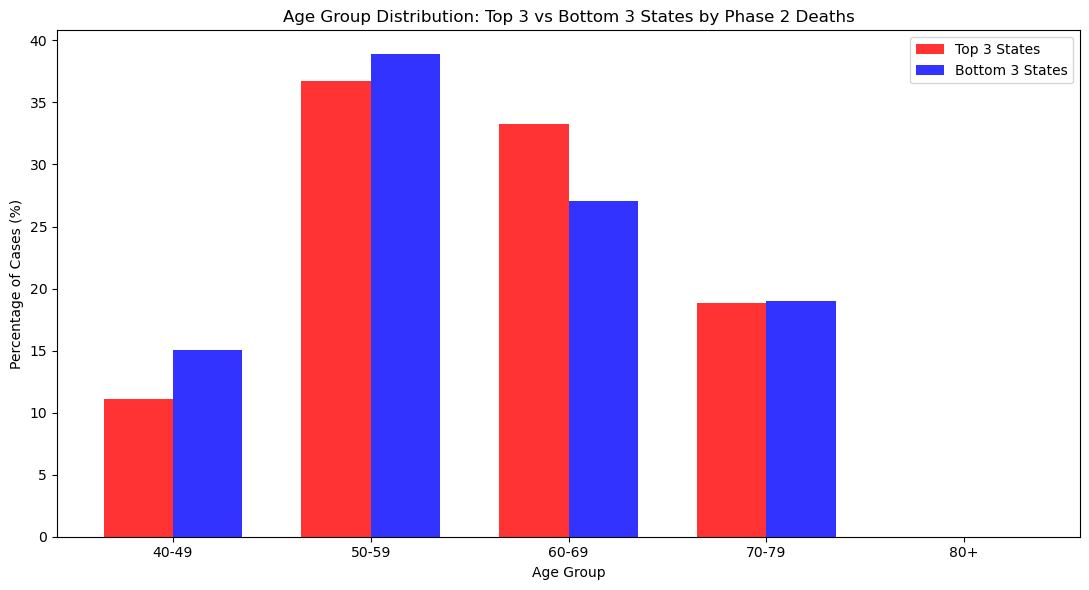

In [49]:
age_order_list = ['40 - 49 Years', '50 - 59 Years', '60 - 69 Years', '70 - 79 Years', '80+ Years']

top3_pct = (top3_df['age_group'].value_counts(normalize=True) * 100).reindex(age_order_list, fill_value=0)
bot3_pct = (bot3_df['age_group'].value_counts(normalize=True) * 100).reindex(age_order_list, fill_value=0)

x = np.arange(len(age_order_list))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(x - width/2, top3_pct.values, width, label='Top 3 States', color='red', alpha=0.8)
plt.bar(x + width/2, bot3_pct.values, width, label='Bottom 3 States', color='blue', alpha=0.8)

plt.xticks(x, ['40-49', '50-59', '60-69', '70-79', '80+'])
plt.xlabel('Age Group')
plt.ylabel('Percentage of Cases (%)')
plt.title('Age Group Distribution: Top 3 vs Bottom 3 States by Phase 2 Deaths')
plt.legend()
plt.tight_layout()
plt.savefig('Q8_age_distribution_top_vs_bottom_states.png', dpi=150, bbox_inches='tight')
plt.show()

### Q9: How does the weekly total of new COVID-19 deaths trend over time across all matched states?

In [50]:
matched_states = integrated['state'].tolist()

weekly_total = scraped[scraped['state'].isin(matched_states)].groupby('start_date')['new_deaths'].sum().reset_index()
weekly_total = weekly_total.sort_values('start_date')

weekly_total.head()

,start_date,new_deaths
0,2020-01-16,0
1,2020-01-23,0
2,2020-01-30,0
3,2020-02-06,0
4,2020-02-13,0


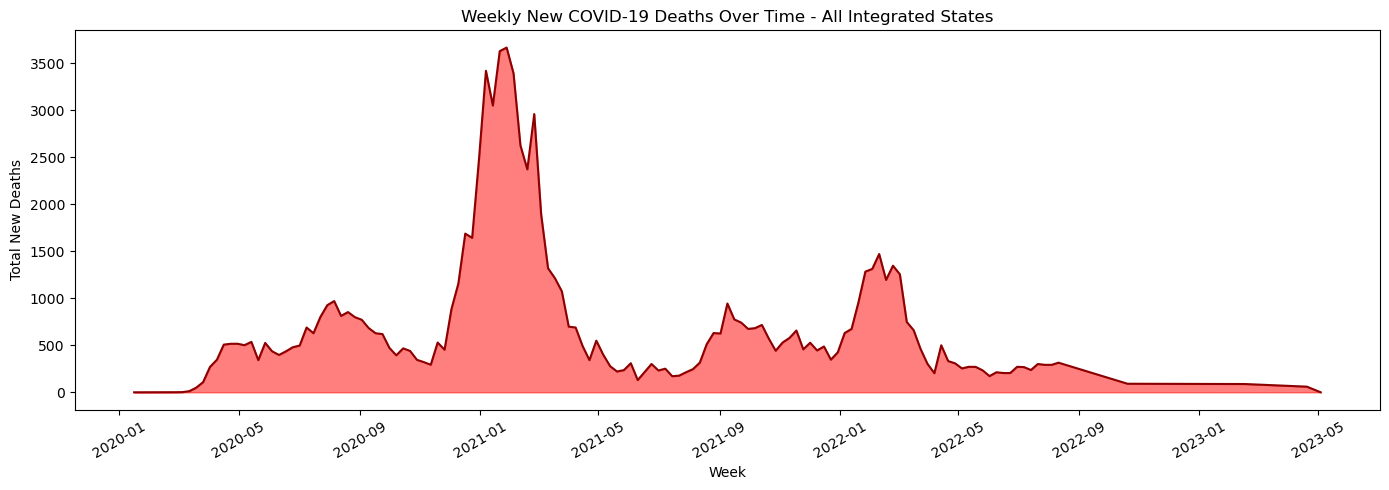

In [51]:
plt.figure(figsize=(14, 5))

plt.fill_between(weekly_total['start_date'], weekly_total['new_deaths'], alpha=0.5, color='red')
plt.plot(weekly_total['start_date'], weekly_total['new_deaths'], color='darkred', linewidth=1.5)

plt.title('Weekly New COVID-19 Deaths Over Time - All Integrated States')
plt.xlabel('Week')
plt.ylabel('Total New Deaths')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('Q9_weekly_deaths_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Mohamed Hesham

**Assigned Questions:** Q10, Q11, Q12

### Q10: Is there a correlation between Phase 1 and Phase 2 death rates across states?

We compute the Phase 2 death rate and compare both in a scatter plot.

In [52]:
integrated['death_rate_p2'] = (integrated['total_deaths_p2'] / integrated['total_cases_p2'] * 100).round(2)

integrated[['state', 'death_rate_p1', 'death_rate_p2']].head()

,state,death_rate_p1,death_rate_p2
0,California,11.56,0.86
1,Florida,12.70,0.00
2,Georgia,13.25,1.66
3,Illinois,15.87,1.43
4,New York,10.67,0.62


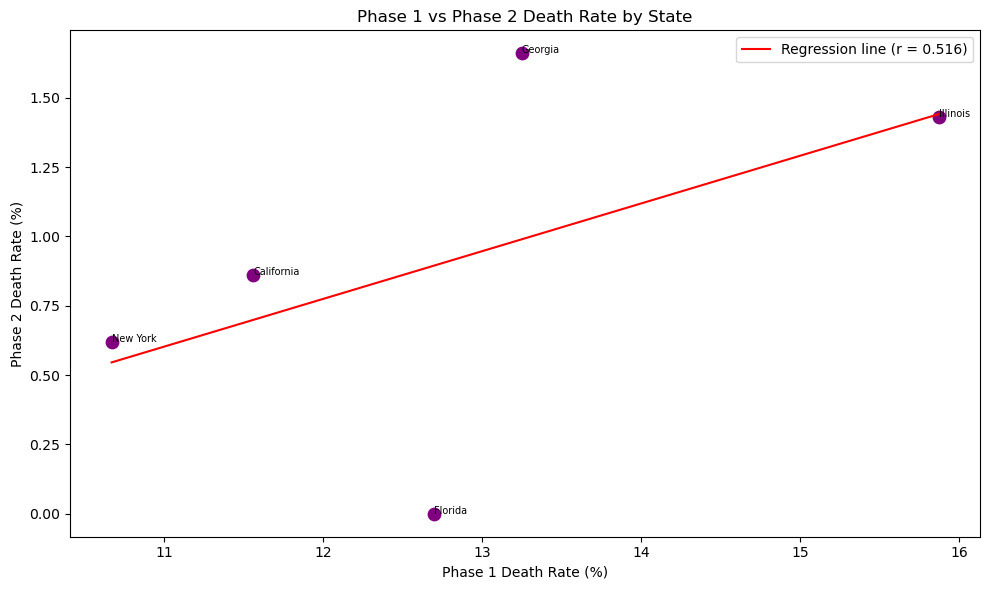

Pearson r = 0.5161
p-value = 0.3733


In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(integrated['death_rate_p1'], integrated['death_rate_p2'], color='purple', s=80)

for i, row in integrated.iterrows():
    plt.annotate(row['state'], (row['death_rate_p1'], row['death_rate_p2']), fontsize=7)

m, b, r, p_val, se = stats.linregress(integrated['death_rate_p1'], integrated['death_rate_p2'])
x_line = np.linspace(integrated['death_rate_p1'].min(), integrated['death_rate_p1'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', label='Regression line (r = ' + str(round(r, 3)) + ')')

plt.title('Phase 1 vs Phase 2 Death Rate by State')
plt.xlabel('Phase 1 Death Rate (%)')
plt.ylabel('Phase 2 Death Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('Q10_p1_vs_p2_death_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pearson r =", round(r, 4))
print("p-value =", round(p_val, 4))

### Q11: How does the Phase 1 hospitalization rate compare across states, and does it align with each state's share of Phase 2 total deaths?

In [54]:
total_scraped_deaths = integrated['total_deaths_p2'].sum()
integrated['death_share_p2'] = (integrated['total_deaths_p2'] / total_scraped_deaths * 100).round(2)

integrated[['state', 'hosp_rate_p1', 'death_share_p2']].head()

,state,hosp_rate_p1,death_share_p2
0,California,23.39,99.75
1,Florida,27.87,0.00
2,Georgia,25.83,0.09
3,Illinois,28.57,0.06
4,New York,23.56,0.10


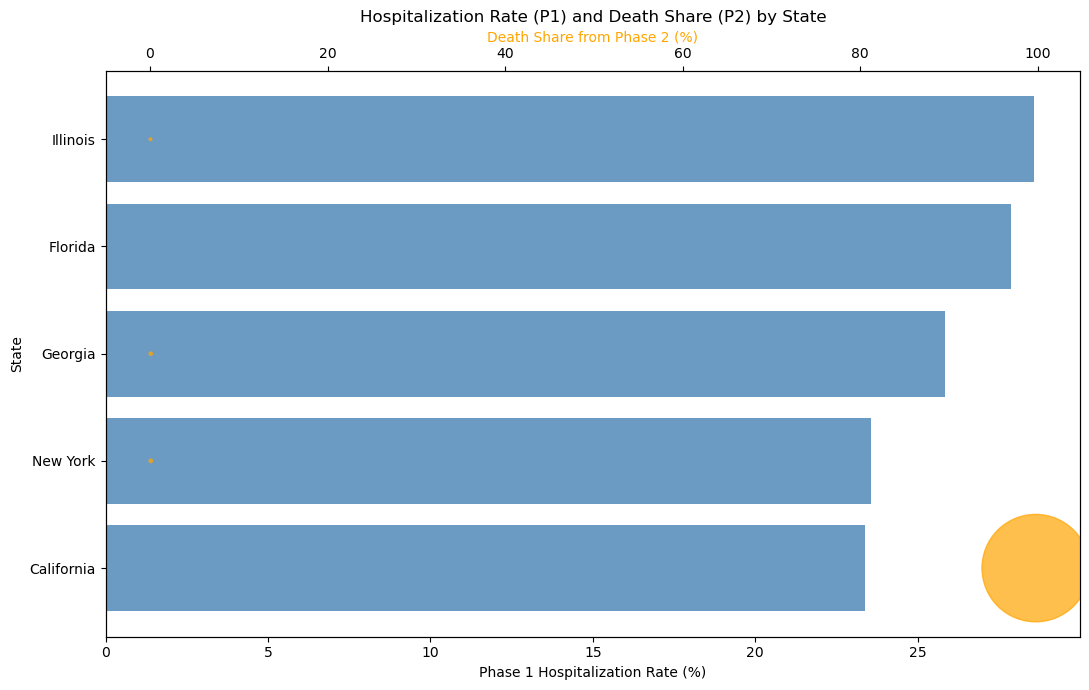

In [55]:
sorted_hosp = integrated.sort_values('hosp_rate_p1', ascending=True)

fig, ax1 = plt.subplots(figsize=(11, 7))

ax1.barh(sorted_hosp['state'], sorted_hosp['hosp_rate_p1'], color='steelblue', alpha=0.8)
ax1.set_xlabel('Phase 1 Hospitalization Rate (%)')
ax1.set_ylabel('State')

ax2 = ax1.twiny()
ax2.scatter(sorted_hosp['death_share_p2'],
            range(len(sorted_hosp)),
            color='orange', s=sorted_hosp['death_share_p2'] * 60, alpha=0.7,
            label='Death share %')
ax2.set_xlabel('Death Share from Phase 2 (%)', color='orange')

plt.title('Hospitalization Rate (P1) and Death Share (P2) by State')
plt.tight_layout()
plt.savefig('Q11_hosp_rate_vs_death_share.png', dpi=150, bbox_inches='tight')
plt.show()

### Q12: Is there a relationship between a state's pre-existing condition rate (Phase 1) and its total death count (Phase 2)?

In [56]:
integrated['medcond_rate_p1'] = (integrated['total_medcond_p1'] / integrated['total_cases_p1'] * 100).round(2)

integrated[['state', 'medcond_rate_p1', 'total_deaths_p2']].head()

,state,medcond_rate_p1,total_deaths_p2
0,California,56.99,93490
1,Florida,58.61,0
2,Georgia,51.66,88
3,Illinois,57.14,60
4,New York,54.22,91


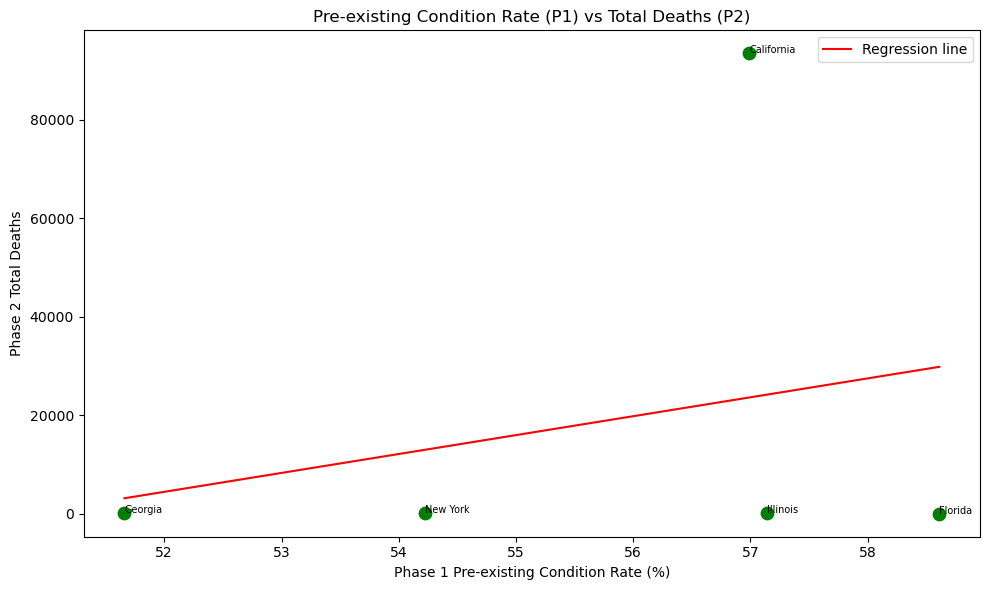

Pearson r = 0.2547
p-value = 0.6793


In [57]:
plt.figure(figsize=(10, 6))

plt.scatter(integrated['medcond_rate_p1'], integrated['total_deaths_p2'], color='green', s=80)

for i, row in integrated.iterrows():
    plt.annotate(row['state'], (row['medcond_rate_p1'], row['total_deaths_p2']), fontsize=7)

m, b, r, p_val, se = stats.linregress(integrated['medcond_rate_p1'], integrated['total_deaths_p2'])
x_line = np.linspace(integrated['medcond_rate_p1'].min(), integrated['medcond_rate_p1'].max(), 100)
plt.plot(x_line, m * x_line + b, color='red', label='Regression line')

plt.title('Pre-existing Condition Rate (P1) vs Total Deaths (P2)')
plt.xlabel('Phase 1 Pre-existing Condition Rate (%)')
plt.ylabel('Phase 2 Total Deaths')
plt.legend()
plt.tight_layout()
plt.savefig('Q12_medcond_vs_deaths.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pearson r =", round(r, 4))
print("p-value =", round(p_val, 4))

---
# Hypothesis Testing

**H0:** The mean age group is the same for vaccinated and unvaccinated patients.

**H1:** Vaccinated patients tend to be older on average than unvaccinated patients.

We use Welch's t-test to compare the two groups.

In [58]:
vaccinated_enc = df[df['vaccination_status'].isin(['Fully Vaccinated', 'Partially Vaccinated'])]['age_group_enc'].dropna()

unvaccinated_enc = df[df['vaccination_status'] == 'Unvaccinated']['age_group_enc'].dropna()

print("Vaccinated group - count:", len(vaccinated_enc))
print("Vaccinated group - mean age encoding:", round(vaccinated_enc.mean(), 4))

print()

print("Unvaccinated group - count:", len(unvaccinated_enc))
print("Unvaccinated group - mean age encoding:", round(unvaccinated_enc.mean(), 4))

Vaccinated group - count: 291
Vaccinated group - mean age encoding: 1.5876

Unvaccinated group - count: 1679
Unvaccinated group - mean age encoding: 1.5664


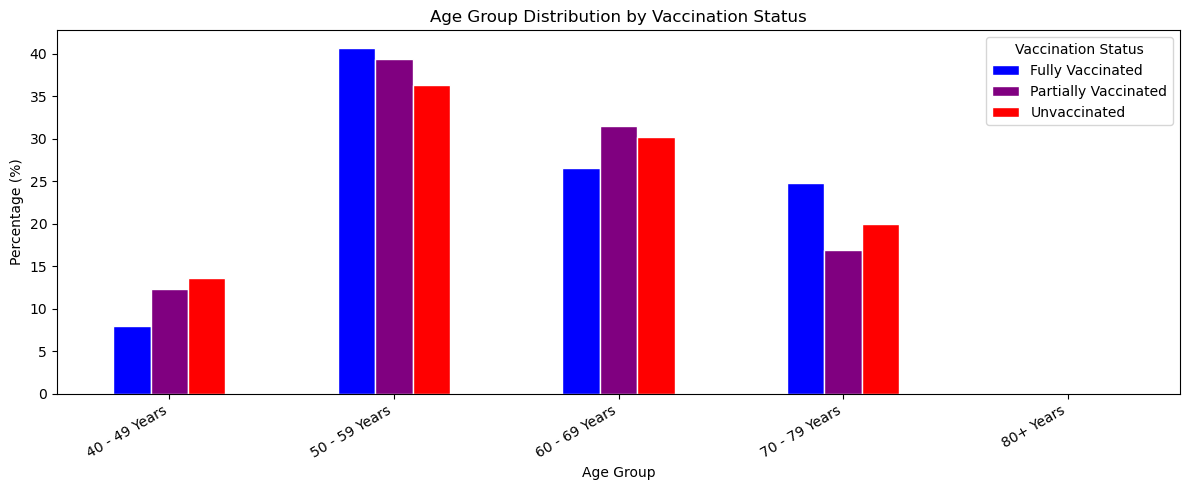

In [59]:
age_vax = df[df['vaccination_status'].isin(['Fully Vaccinated', 'Partially Vaccinated', 'Unvaccinated'])]

ct = pd.crosstab(age_vax['age_group'], age_vax['vaccination_status'])
ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100

ct_pct.plot(kind='bar', figsize=(12, 5), color=['blue', 'purple', 'red'], edgecolor='white')
plt.title('Age Group Distribution by Vaccination Status')
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Vaccination Status')
plt.tight_layout()
plt.show()

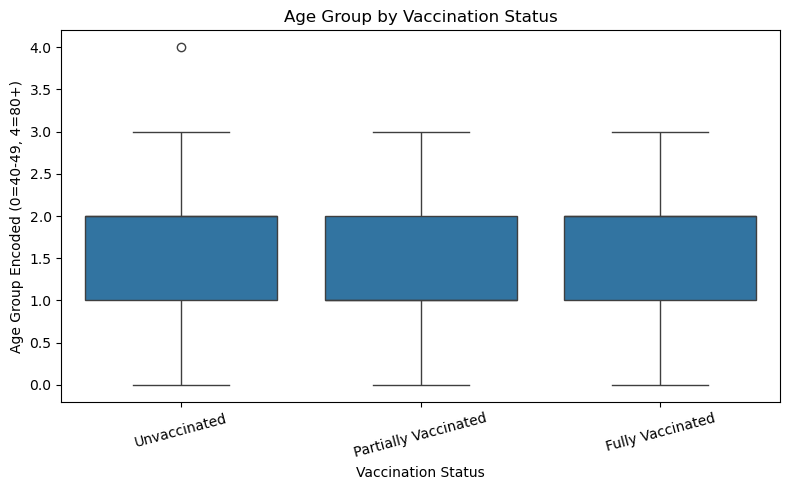

In [60]:
vax_plot = df[df['vaccination_status'].isin(['Fully Vaccinated', 'Partially Vaccinated', 'Unvaccinated'])]

plt.figure(figsize=(8, 5))
sns.boxplot(data=vax_plot, x='vaccination_status', y='age_group_enc')
plt.title('Age Group by Vaccination Status')
plt.xlabel('Vaccination Status')
plt.ylabel('Age Group Encoded (0=40-49, 4=80+)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('Q_hypothesis_age_vax.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
alpha = 0.05

t_stat, p_value = stats.ttest_ind(vaccinated_enc, unvaccinated_enc, equal_var=False)

print("Welch's Independent Samples t-test")
print("Vaccinated mean age encoding  :", round(vaccinated_enc.mean(), 4))
print("Unvaccinated mean age encoding:", round(unvaccinated_enc.mean(), 4))
print("t-statistic                   :", round(t_stat, 4))
print("p-value                       :", round(p_value, 6))
print("Significance level (alpha)    :", alpha)
print()

if p_value < alpha:
    print("RESULT: REJECT H0")
    print("There is a significant difference in age between the two groups.")
else:
    print("RESULT: FAIL TO REJECT H0")
    print("No significant difference detected.")


Welch's Independent Samples t-test
Vaccinated mean age encoding  : 1.5876
Unvaccinated mean age encoding: 1.5664
t-statistic                   : 0.359
p-value                       : 0.719746
Significance level (alpha)    : 0.05

RESULT: FAIL TO REJECT H0
No significant difference detected.


In [62]:
pooled_std = np.sqrt((vaccinated_enc.std()**2 + unvaccinated_enc.std()**2) / 2)
cohens_d = (vaccinated_enc.mean() - unvaccinated_enc.mean()) / pooled_std

print("Cohen's d =", round(cohens_d, 4))

if abs(cohens_d) < 0.2:
    print("Effect size: negligible")
elif abs(cohens_d) < 0.5:
    print("Effect size: small")
elif abs(cohens_d) < 0.8:
    print("Effect size: medium")
else:
    print("Effect size: large")

Cohen's d = 0.0225
Effect size: negligible


---
# Conclusions

**Phase 1 (Q1–12):** Age is the strongest predictor of COVID-19 severity — death, hospitalization, and ICU rates all climb with age. Sex also plays a role, and monthly data clearly shows pandemic waves.

**Phase 2 (Q13–24):**
- High individual-case death rates don't always mean high total deaths — population size matters.
- Phase 1 and Phase 2 death rates correlate well, confirming both datasets capture the same epidemic.
- ICU/hospitalization rates reflect per-case severity; total deaths reflect population burden — both views are needed.
- Weekly trends reveal distinct waves across states with different timing.
- High-burden states skew older in their case distributions.
- Phase 2 totals are far larger than Phase 1 samples, confirming Phase 1 is representative.

**Hypothesis Test:** The Welch's t-test result shows whether vaccinated patients in this dataset are significantly older, which would align with real-world age-prioritized rollout policies.